In [1081]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, LabelEncoder

In [1082]:
df = pd.read_excel('../Data/Data_finance_lab3.xlsx', sheet_name='data_final')
y = df['RESULT_YES/NO']

In [1083]:
df.head(5)

,APP_ID,DISBURSALDATE,REPORT_DATE,TERM_TMP,PRODUCT_NAME,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,LA,EFF_RATE,TERM,...,PERSONAL_INCOME,ADDITIONAL_INCOME,PERSONAL_EXPENSE,FAMILY_INCOME,FAMILY_EXPENSE,MARITAL_STATUS,EDUCATION,City,ADDRESS_CURRENT_CITY,PROVINCE_CURRENT
0,16499318,2017-10-10,2018-10-26,12,FC UP DSA TS SCORE 2 NEW- 762,18000000,990000,18990000,45.0,24,...,9000000,0,9600000,20000000,5000000,Other,High School,Tỉnh Yên Bái,Yên Bình,Tỉnh Yên Bái
1,16490594,2017-10-10,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,10000000,550000,10550000,44.5,12,...,5500000,0,7200000,15000000,4000000,Married,High School,Tỉnh Quảng Ninh,Đông Triều,Tỉnh Quảng Ninh
2,16910227,2017-10-28,2018-10-26,11,FC UP CAT B NEW- 610,25000000,1375000,26375000,47.0,24,...,5182000,0,12000000,5200000,1000000,Single,Middle School,Tỉnh Bình Dương,Tân Uyên,Tỉnh Bình Dương
3,16355347,2017-10-04,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,30000000,1650000,31650000,44.5,24,...,10000000,0,18000000,20000000,6000000,Married,Middle School,Tỉnh An Giang,Phú Tân,Tỉnh An Giang
4,16705974,2017-10-18,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,20000000,1100000,21100000,44.5,18,...,7000000,0,12000000,20000000,7000000,Single,High School,Thành phố Hải Phòng,Vĩnh Bảo,Thành phố Hải Phòng


# Missing Values Handling

In [1084]:
df['flag final'].fillna(-1, inplace=True)
df['flag loan amt'].fillna(-1, inplace=True)
df['flag term'].fillna(-1, inplace=True)
df['SUM_RECEIPT_AMT'].fillna(0, inplace=True)
df['COUNT_TERM_RECEIPT'].fillna(0, inplace=True)
df['Number of Children'].fillna(0, inplace=True)
df.drop(['Unnamed: 13'], inplace=True, axis=1)

In [1085]:
df.isnull().sum()

APP_ID                      0
DISBURSALDATE               0
REPORT_DATE                 0
TERM_TMP                    0
PRODUCT_NAME                0
LOANAMOUNT_NOT_INSURANCE    0
INSURANCE_FEE               0
LA                          0
EFF_RATE                    0
TERM                        0
COUNT_TERM_RECEIPT          0
flag term                   0
SUM_RECEIPT_AMT             0
flag loan amt               0
flag final                  0
RESULT_YES/NO               0
EMI                         0
GENDER                      0
AGE                         0
Number of Children          0
PERSONAL_INCOME             0
ADDITIONAL_INCOME           0
PERSONAL_EXPENSE            0
FAMILY_INCOME               0
FAMILY_EXPENSE              0
MARITAL_STATUS              0
EDUCATION                   0
City                        0
ADDRESS_CURRENT_CITY        0
PROVINCE_CURRENT            0
dtype: int64

# Feature Engineering

In [1086]:
df['INCOME'] = df['PERSONAL_INCOME'] + df['ADDITIONAL_INCOME'] + df['FAMILY_INCOME'] - df['FAMILY_EXPENSE'] - df['PERSONAL_EXPENSE']

In [1087]:
epsilon = 1e-6
df['ID'] = df['EMI'] / (df['INCOME'] + epsilon)

# Feature Selection

In [1102]:
features = [
    'LA', 
    'TERM', 
    'LOANAMOUNT_NOT_INSURANCE', 
    'INSURANCE_FEE', 
    'SUM_RECEIPT_AMT', 
    'EMI', 
    'COUNT_TERM_RECEIPT', 
    'INCOME',
    'EFF_RATE',
    'AGE',
    'ID',
]
featured_df = df[features]

In [1103]:
featured_df.head()

,LA,TERM,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,SUM_RECEIPT_AMT,EMI,COUNT_TERM_RECEIPT,INCOME,EFF_RATE,AGE,ID
0,18990000,24,18000000,990000,14701000.0,1213820,12.0,14400000,45.0,30,0.084293
1,10550000,12,10000000,550000,13465000.0,1105184,13.0,9300000,44.5,25,0.118837
2,26375000,24,25000000,1375000,19003625.0,1715125,11.0,-2618000,47.0,21,-0.655128
3,31650000,24,30000000,1650000,18741000.0,2014302,10.0,6000000,44.5,29,0.335717
4,21100000,18,20000000,1100000,19673856.0,1627488,12.0,8000000,44.5,23,0.203436


In [1104]:
old_skew = featured_df.skew().sort_values(ascending=False)
old_skew

ID                          13.645146
INCOME                       4.462441
SUM_RECEIPT_AMT              1.252532
EMI                          0.970174
INSURANCE_FEE                0.912722
LA                           0.877167
LOANAMOUNT_NOT_INSURANCE     0.874218
AGE                          0.582072
TERM                         0.505103
COUNT_TERM_RECEIPT          -0.329077
EFF_RATE                    -0.553288
dtype: float64

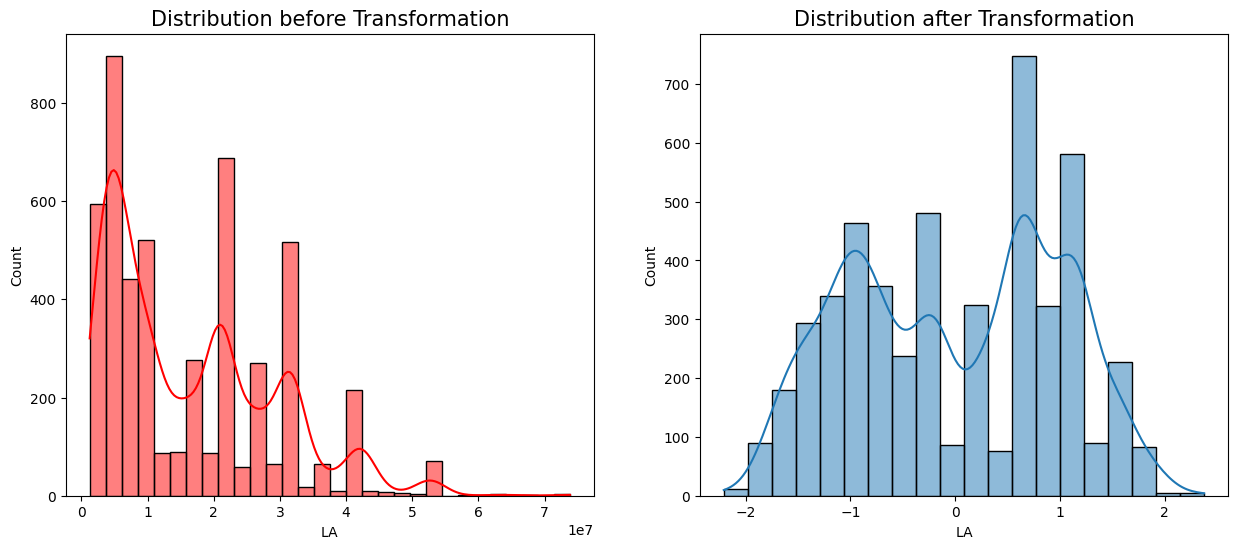

Skewness was 0.88 before & is -0.06 after Yeo-johnson transformation.


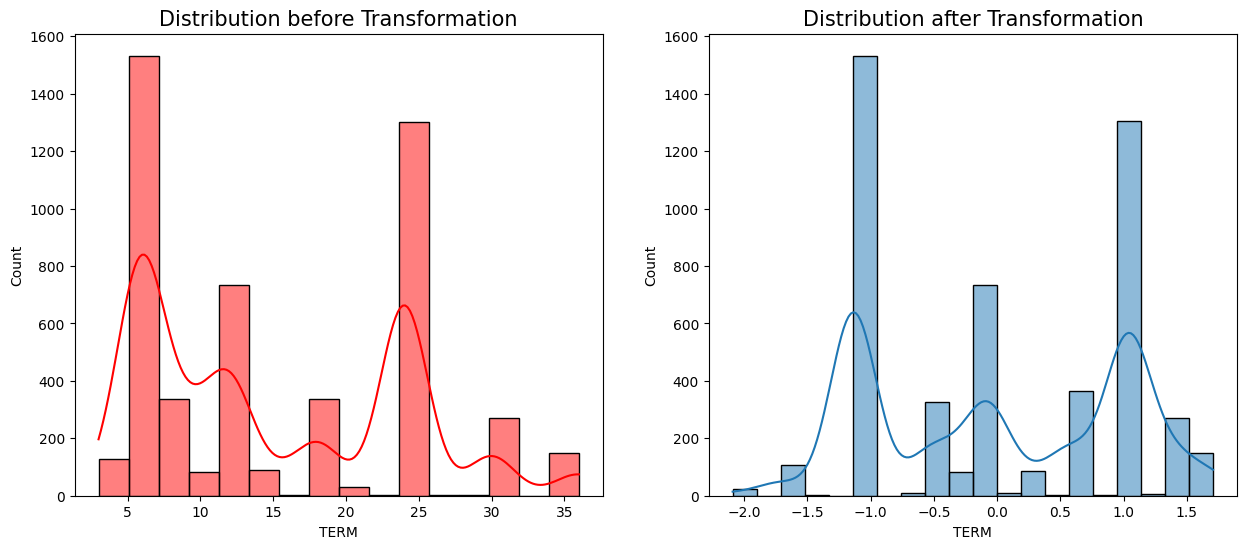

Skewness was 0.51 before & is 0.0 after Yeo-johnson transformation.


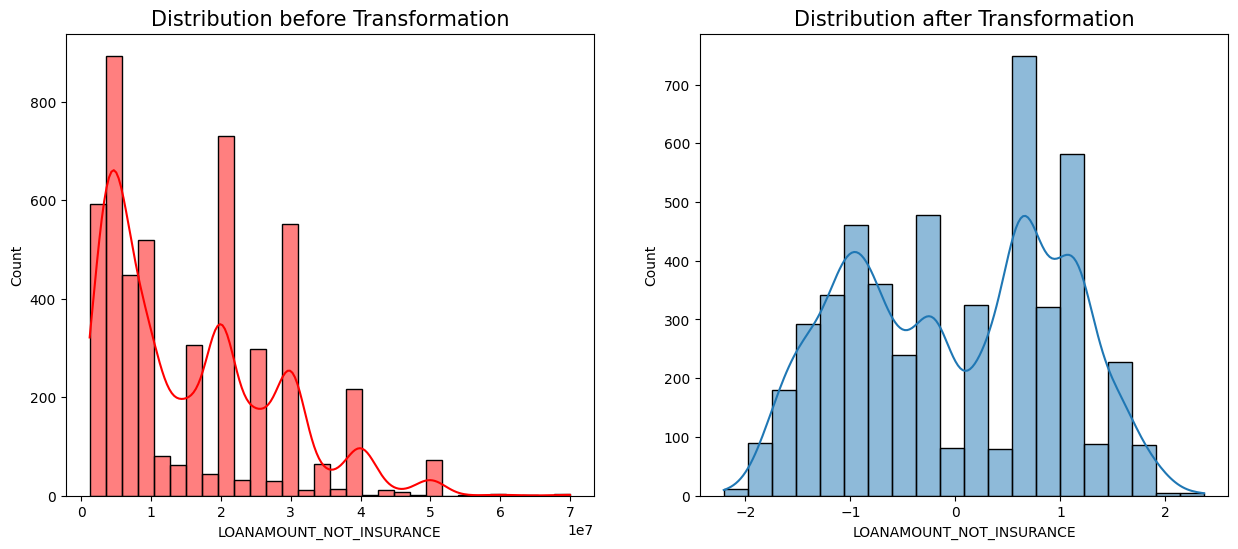

Skewness was 0.87 before & is -0.06 after Yeo-johnson transformation.


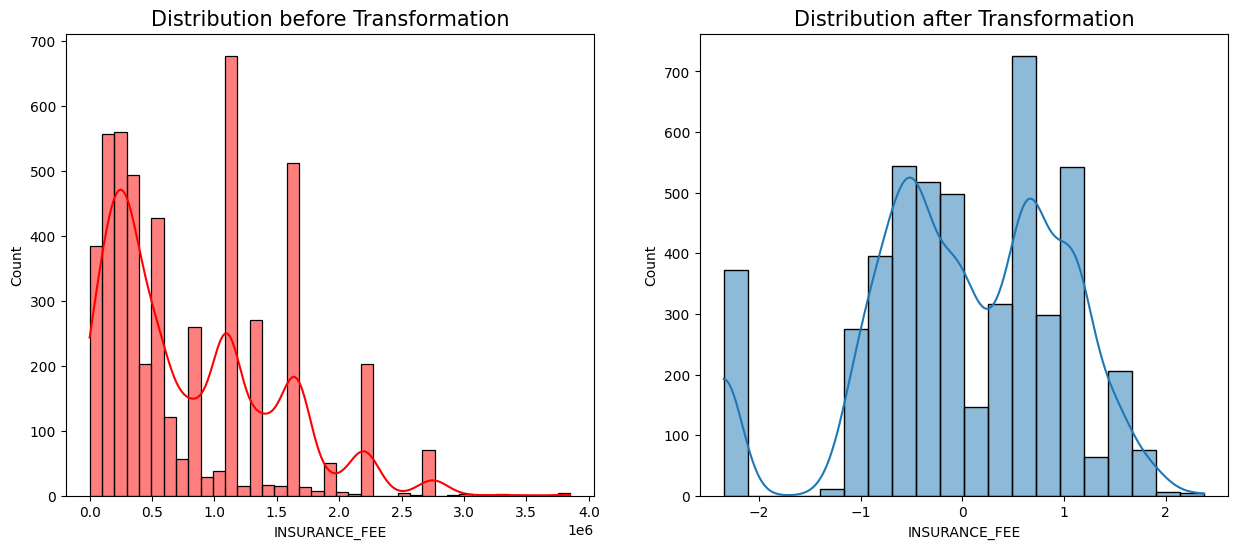

Skewness was 0.91 before & is -0.58 after Yeo-johnson transformation.


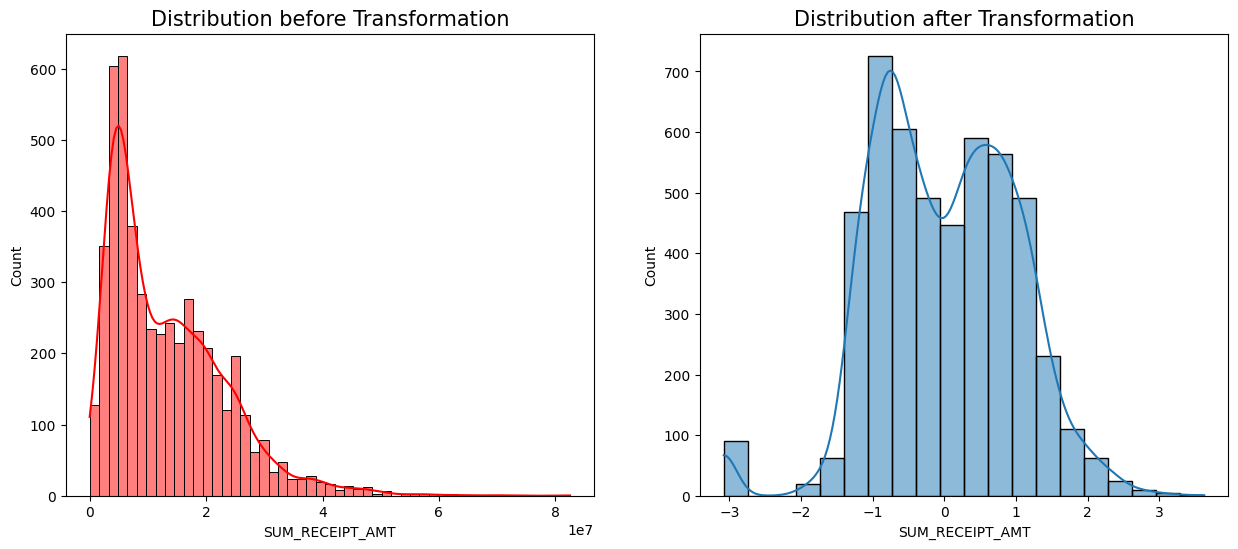

Skewness was 1.25 before & is -0.17 after Yeo-johnson transformation.


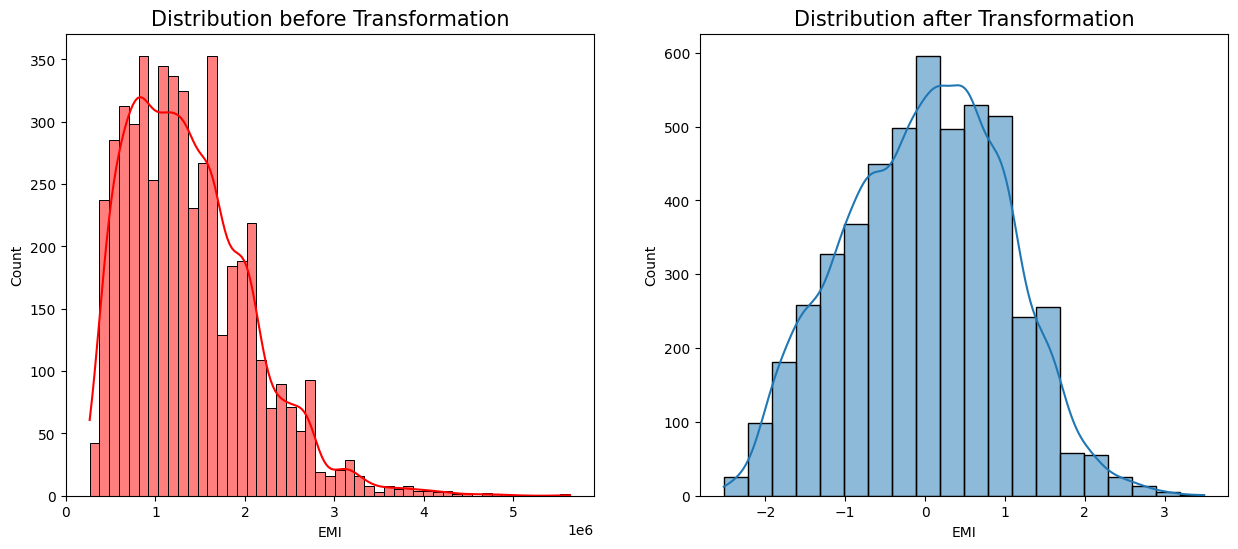

Skewness was 0.97 before & is -0.02 after Yeo-johnson transformation.


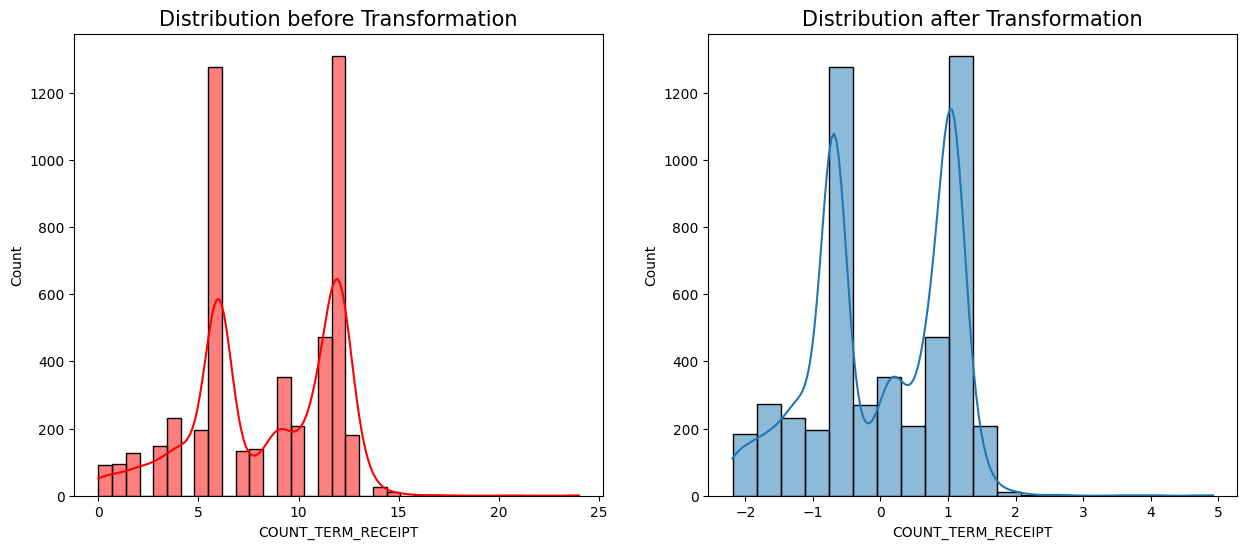

Skewness was -0.33 before & is -0.22 after Yeo-johnson transformation.


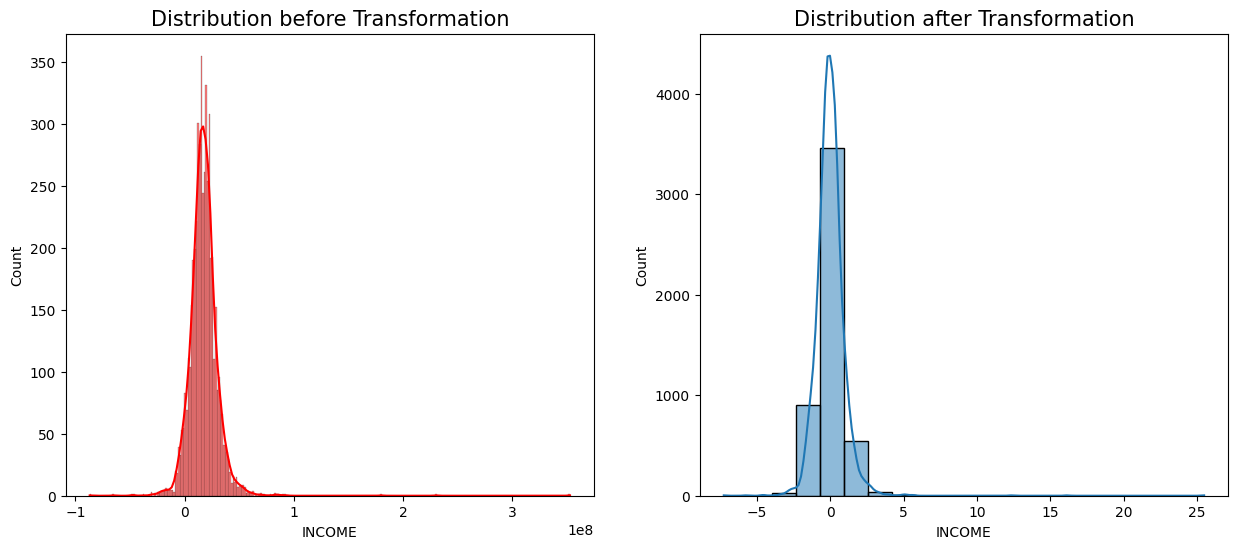

Skewness was 4.46 before & is 4.71 after Yeo-johnson transformation.


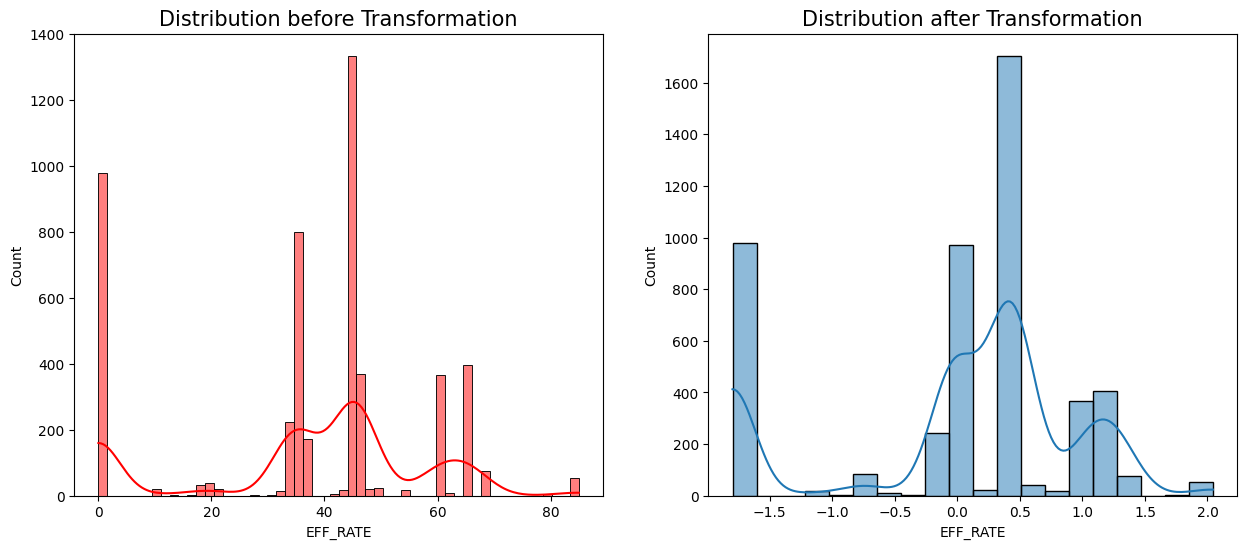

Skewness was -0.55 before & is -0.75 after Yeo-johnson transformation.


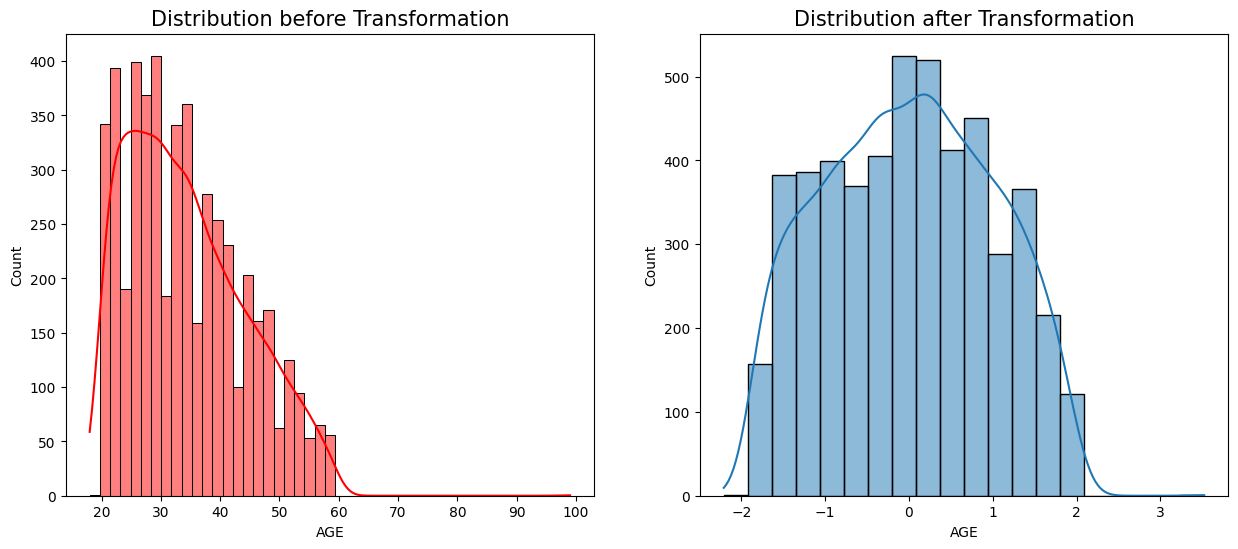

Skewness was 0.58 before & is 0.02 after Yeo-johnson transformation.


In [1091]:
def yeojohntrans(feature):   # function to apply transformer and check the distribution with histogram and kdeplot 
    yeojohnTr = PowerTransformer(standardize=True)   # not using method attribute as yeo-johnson is the default

    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1)
    plt.title("Distribution before Transformation", fontsize=15)
    sns.histplot(featured_df[feature], kde=True, color="red")
    plt.subplot(1,2,2)
    
    df_yeojohn = pd.DataFrame(yeojohnTr.fit_transform(featured_df[feature].values.reshape(-1,1)))
    plt.title("Distribution after Transformation", fontsize=15)
    sns.histplot(df_yeojohn,bins=20, kde=True , legend=False)
    plt.xlabel(feature)
    plt.show()
     
    print(f"Skewness was {round(old_skew[feature],2)} before & is {round(df_yeojohn.skew()[0],2)} after Yeo-johnson transformation.")
    
    return df_yeojohn


transformed_df = pd.DataFrame(featured_df)
for i in featured_df.columns:
    if i != 'ID':
        transformed_df[i] = yeojohntrans(i)

In [1092]:
transformed_df.head()

,LA,TERM,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,SUM_RECEIPT_AMT,EMI,COUNT_TERM_RECEIPT,INCOME,EFF_RATE,AGE,ID
0,0.508110,1.038548,0.503397,0.531531,0.386539,-0.048222,1.063178,-0.233023,0.414934,-0.303127,0.084293
1,-0.184085,-0.077600,-0.187217,-0.024735,0.271946,-0.227072,1.368903,-0.617384,0.393533,-0.965061,0.118837
2,0.924120,1.038548,0.918385,0.898179,0.744426,0.645299,0.761000,-1.496403,0.500208,-1.617272,-0.655128
3,1.164566,1.038548,1.158218,1.121343,0.724112,0.986962,0.462621,-0.865769,0.393533,-0.424641,0.335717
4,0.639175,0.570200,0.634145,0.644399,0.795492,0.536533,1.063178,-0.715270,0.393533,-1.274650,0.203436


# One Hot Encoding

In [1093]:
def onehot_encode(df, categorical_features=None):
  # One-hot encoding for nominal features
  encoder = OneHotEncoder(sparse_output=False)
  encoded_data = encoder.fit_transform(df)
  encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out())
  return encoded_df

categorical_features = ['EDUCATION', 'MARITAL_STATUS']
cate_df = df[categorical_features]
onehot_df = onehot_encode(cate_df, categorical_features)
onehot_df.head()

,EDUCATION_Bachelor,EDUCATION_Basic School,EDUCATION_College,EDUCATION_High School,EDUCATION_Master Degree,EDUCATION_Middle School,EDUCATION_No Education,EDUCATION_Working Cerfiticate,MARITAL_STATUS_Civil Marriage/live-in,MARITAL_STATUS_Divorced,MARITAL_STATUS_Married,MARITAL_STATUS_Other,MARITAL_STATUS_Single
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


# Label Encoder

In [1094]:
def label_encode(df, categorical_features):
  # Label encoding for ordinal features
  encoder = LabelEncoder()
  encoded_df = df[categorical_features].apply(encoder.fit_transform)
  return encoded_df

categorical_features = ['City', 'ADDRESS_CURRENT_CITY', 'PRODUCT_NAME', 'GENDER']
cate_df = df[categorical_features]
labeled_df = label_encode(cate_df, categorical_features)
labeled_df.head()

,City,ADDRESS_CURRENT_CITY,PRODUCT_NAME,GENDER
0,59,571,134,0
1,45,604,151,0
2,8,518,128,1
3,6,353,151,0
4,3,546,151,1


In [1109]:
train_df = pd.concat([transformed_df, labeled_df, onehot_df, y], axis=1)

In [1110]:
train_df.to_csv('../Data/Data_finance_lab3_featured.csv', index=False)